In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
dataset = fetch_ucirepo(id=697)
X = dataset.data.features
y = dataset.data.targets
df = pd.concat([X, y], axis=1)


**handle missing values**

In [ ]:


df.isnull().sum()          # count per column
df.isnull().sum().sum()    # total missing values

np.int64(0)

**Duplicate records**

In [ ]:
df.duplicated().sum()      # count of duplicate rows
df = df.drop_duplicates()  # remove them if any exist

**correct data types**

In [ ]:
df.dtypes
df.describe()               # spot-check ranges for anything odd (e.g. negative ages)


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


**Encode the target **

In [ ]:
df['Target_binary'] = (df['Target'] == 'Dropout').astype(int)
df['Target_binary'].value_counts()



,count
Target_binary,
0,3003
1,1421


** Final check**

In [ ]:
df.shape
df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Target_binary
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,0



***Phase-4***

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

 **Target distribution**

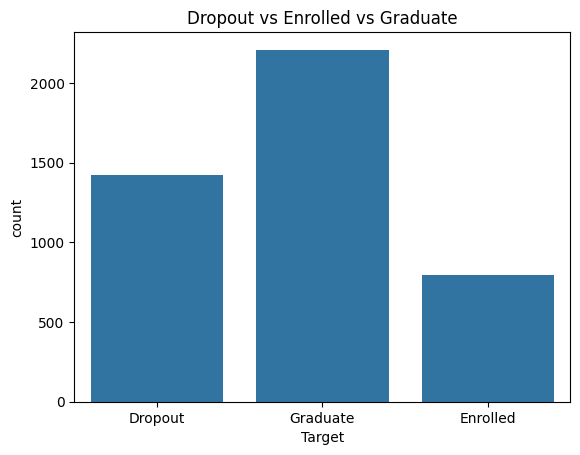

In [ ]:
df['Target'].value_counts()
sns.countplot(data=df, x='Target')
plt.title('Dropout vs Enrolled vs Graduate')
plt.show()

**Statistical summary of numeric features**

In [ ]:
df.describe()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target_binary
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,0.321203
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,0.466991
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,0.000000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,0.000000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,0.000000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,1.000000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000,1.000000


**Academic** performance vs Target

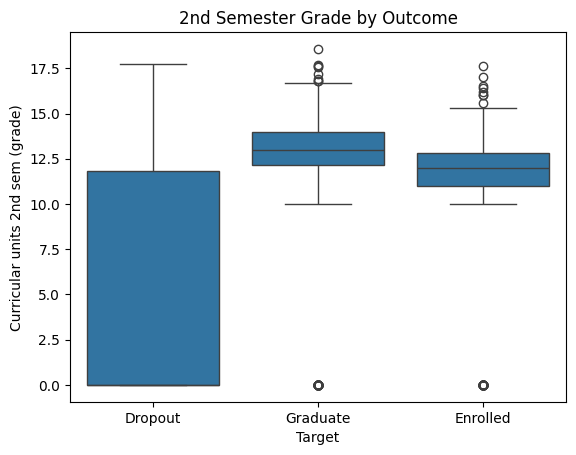

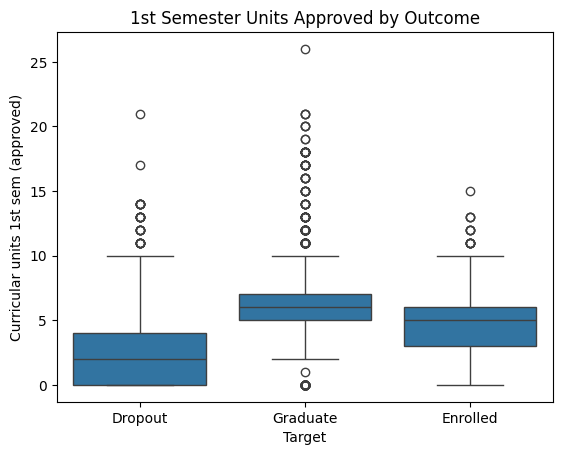

In [ ]:
sns.boxplot(data=df, x='Target', y='Curricular units 2nd sem (grade)')
plt.title('2nd Semester Grade by Outcome')
plt.show()

sns.boxplot(data=df, x='Target', y='Curricular units 1st sem (approved)')
plt.title('1st Semester Units Approved by Outcome')
plt.show()

**Categorical/binary features vs Target **

In [ ]:
pd.crosstab(df['Tuition fees up to date'], df['Target'], normalize='index')
pd.crosstab(df['Scholarship holder'], df['Target'], normalize='index')
pd.crosstab(df['Gender'], df['Target'], normalize='index')
pd.crosstab(df['Debtor'], df['Target'], normalize='index')

Target,Dropout,Enrolled,Graduate
Debtor,,,
0,0.282836,0.179546,0.537618
1,0.620278,0.178926,0.200795


**Age vs Target **

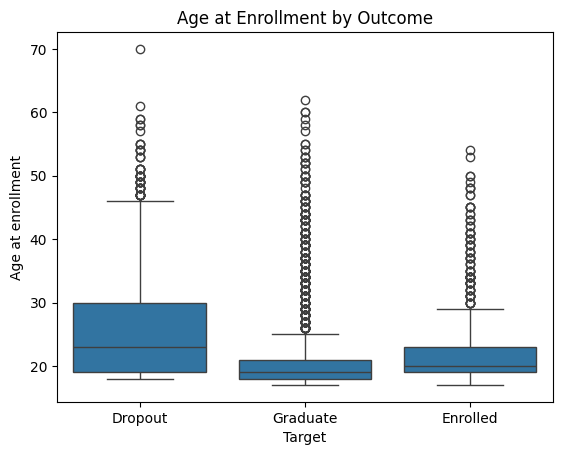

In [ ]:
sns.boxplot(data=df, x='Target', y='Age at enrollment')
plt.title('Age at Enrollment by Outcome')
plt.show()

** Correlation heatmap (numeric features only) **

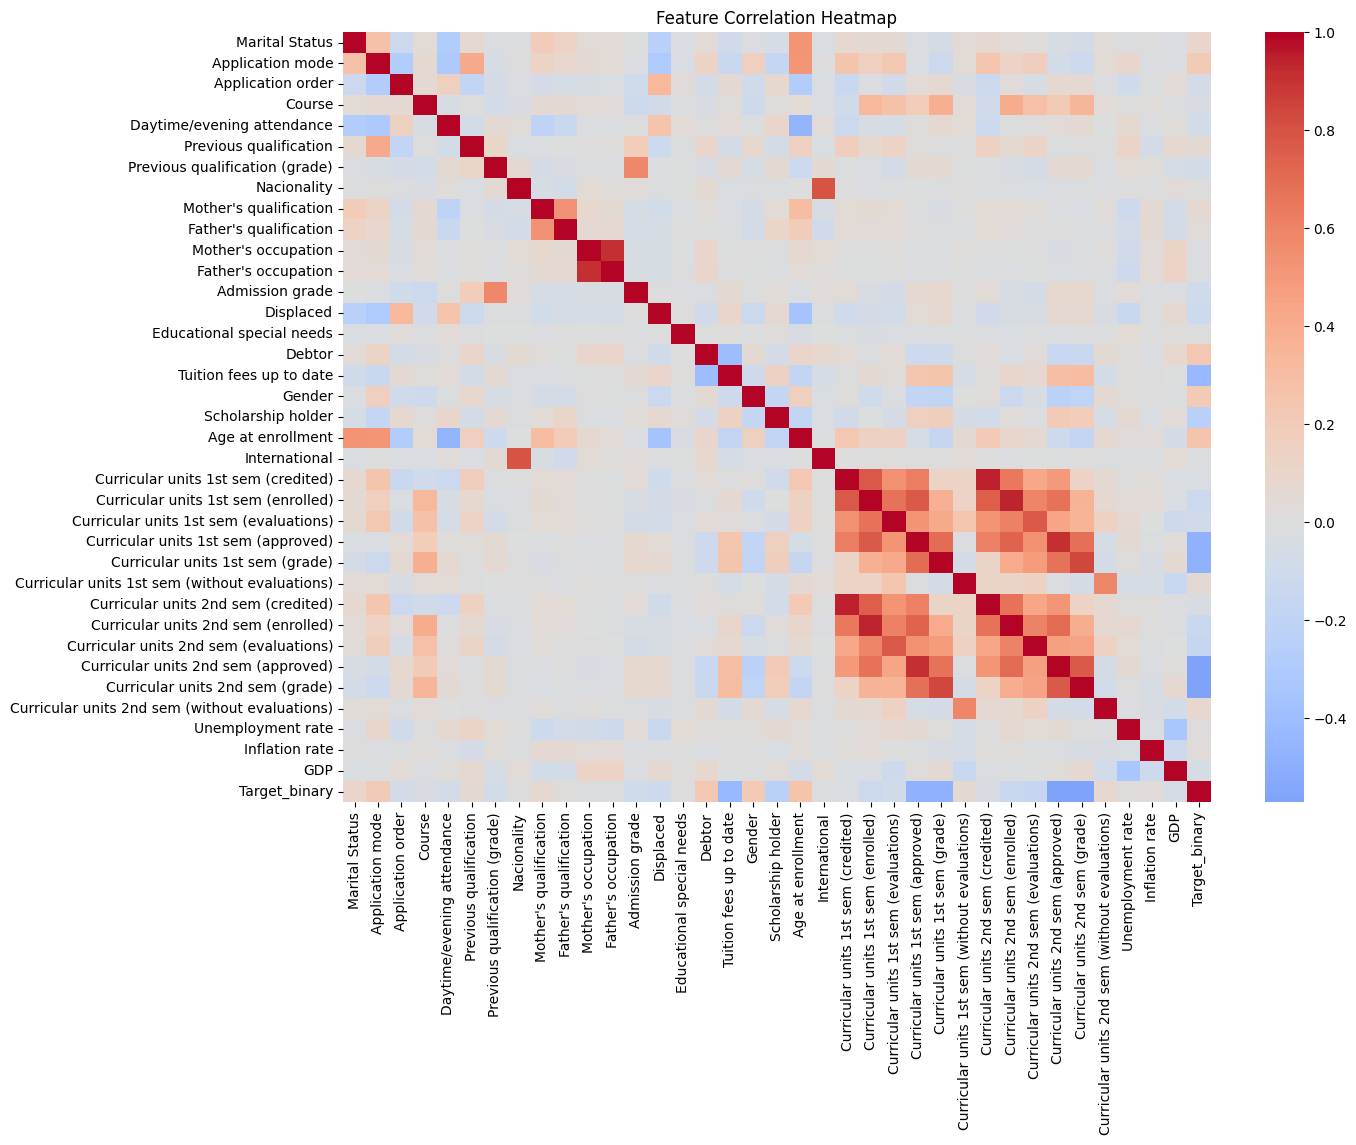

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

**Training the Logistic Regression Model — Phase 5**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


**define features (X) and target (y)**

In [ ]:
X = df.drop(columns=['Target', 'Target_binary'])
y = df['Target_binary']

**Train/test split (80/20)**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (3539, 36)
Testing set shape: (885, 36)


**Scale features (helps Logistic Regression converge)**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Train the model**

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
print("Model trained successfully.")

Model trained successfully.


**Prediction**

In [ ]:
y_pred = model.predict(X_test_scaled)
print("First 10 predictions:", y_pred[:10])
print("First 10 actual values:", y_test[:10].values)

First 10 predictions: [0 0 1 0 1 0 1 1 0 1]
First 10 actual values: [0 0 1 0 1 0 1 1 0 1]


**Prediction probabilities**

In [ ]:
y_pred_proba = model.predict_proba(X_test_scaled)
print("First 5 prediction probabilities (Not Dropout, Dropout):")
print(y_pred_proba[:5])

First 5 prediction probabilities (Not Dropout, Dropout):
[[0.97765291 0.02234709]
 [0.7483755  0.2516245 ]
 [0.02760728 0.97239272]
 [0.97685483 0.02314517]
 [0.0541236  0.9458764 ]]


**Phase 6 — Model Evaluation**

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

**Confusion Matrix**

Confusion Matrix:
 [[575  26]
 [ 75 209]]


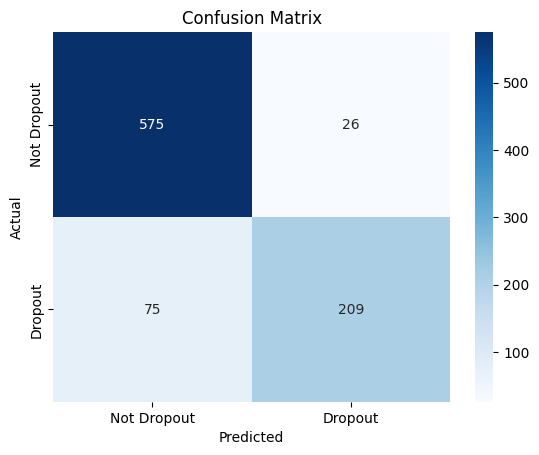

In [ ]:



cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Dropout', 'Dropout'],
            yticklabels=['Not Dropout', 'Dropout'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Classification Report (Precision, Recall, F1 all at once)**

In [ ]:

print(classification_report(y_test, y_pred, target_names=['Not Dropout', 'Dropout']))




              precision    recall  f1-score   support

 Not Dropout       0.88      0.96      0.92       601
     Dropout       0.89      0.74      0.81       284

    accuracy                           0.89       885
   macro avg       0.89      0.85      0.86       885
weighted avg       0.89      0.89      0.88       885



**Individual metrics**

In [ ]:

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


Accuracy:  0.8859
Precision: 0.8894
Recall:    0.7359
F1 Score:  0.8054


**ROC-AUC**

ROC-AUC:   0.9266


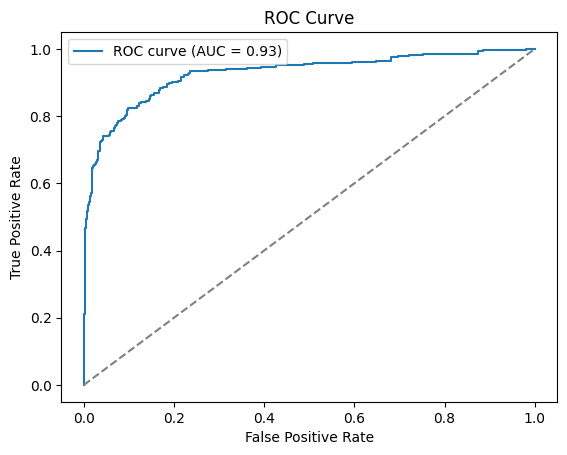

In [ ]:
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"ROC-AUC:   {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()